In [4]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

rng = np.random.default_rng(67)

#### Dataset sintético

In [5]:
m     = 100   # muestras
n     = 1     # features
sigma = 0.8   # ruido

X = rng.normal(size=(m, n))   # [m, n]
w_true = np.array([2.5])      # [n]  weights reales (dos pesos si son dos variables)
b_true = -1.2                 # intercept real

y = X @ w_true + b_true + rng.normal(0, sigma, size=m)  # [m]

#### Diseña la matriz con bias

In [6]:
X_design = np.c_[np.ones((m, 1)), X]  # [m, n+1]

#### Ordinary Least-Squares Estimator (OLS)
$$
\hat{w} = (X^T X)^{-1} X^T y
$$

In [7]:
w_hat = np.linalg.pinv(X_design.T @ X_design) @ (X_design.T @ y)  # (n+1,)

b_hat = w_hat[0]
w_hat_no_bias = w_hat[1:]

y_hat = X_design @ w_hat
residual = y - y_hat

mse = np.mean((y - y_hat)**2)

print(f"b_hat = {b_hat:.4f}")
print(f"w_hat = {w_hat_no_bias}")
print(f"MSE   = {mse:.4f}")

b_hat = -1.1085
w_hat = [2.58502257]
MSE   = 0.6488


#### Visualización

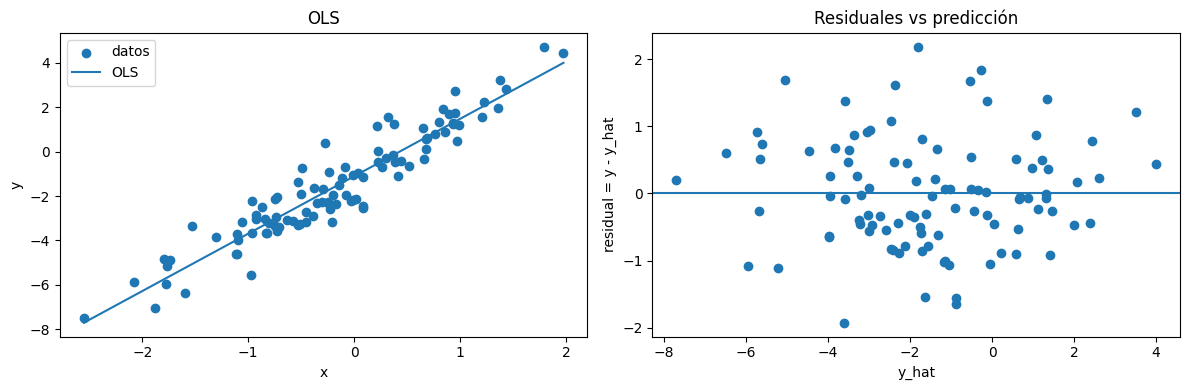

In [8]:
if n == 1:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    x_plot = np.linspace(X.min(), X.max(), 200)
    Xp = np.c_[np.ones((x_plot.shape[0], 1)), x_plot.reshape(-1, 1)]
    y_plot = Xp @ w_hat

    axes[0].scatter(X[:, 0], y, label="datos")
    axes[0].plot(x_plot, y_plot, label="OLS")
    axes[0].set_xlabel("x")
    axes[0].set_ylabel("y")
    axes[0].set_title("OLS")
    axes[0].legend()

    axes[1].scatter(y_hat, residual)
    axes[1].axhline(0)
    axes[1].set_xlabel("y_hat")
    axes[1].set_ylabel("residual = y - y_hat")
    axes[1].set_title("Residuales vs predicción")

    plt.tight_layout()
    plt.show()


elif n == 2:
    fig = plt.figure(figsize=(12, 4))

    ax1 = fig.add_subplot(1, 2, 1, projection="3d")
    ax1.scatter(X[:, 0], X[:, 1], y, label="datos")

    x1 = np.linspace(X[:, 0].min(), X[:, 0].max(), 30)
    x2 = np.linspace(X[:, 1].min(), X[:, 1].max(), 30)
    X1g, X2g = np.meshgrid(x1, x2)

    Xp_grid = np.c_[
        np.ones(X1g.size),
        X1g.ravel(),
        X2g.ravel()
    ]
    y_grid = (Xp_grid @ w_hat).reshape(X1g.shape)

    ax1.plot_surface(X1g, X2g, y_grid, alpha=0.4)
    ax1.set_xlabel("x1")
    ax1.set_ylabel("x2")
    ax1.set_zlabel("y")
    ax1.set_title("OLS: plano ajustado")

    ax2 = fig.add_subplot(1, 2, 2)
    ax2.scatter(y_hat, residual)
    ax2.axhline(0)
    ax2.set_xlabel("y_hat")
    ax2.set_ylabel("residual = y - y_hat")
    ax2.set_title("Residuales vs predicción")

    plt.tight_layout()
    plt.show()

## Analisis

In [9]:
def ols_fit(X, y):
    m = X.shape[0]
    X_design = np.c_[np.ones((m, 1)), X]
    w_hat = np.linalg.pinv(X_design) @ y
    y_hat = X_design @ w_hat
    residual = y - y_hat
    return w_hat, y_hat, residual, X_design

In [10]:
def summarize_orthogonality(X_design, residual):
    v = X_design.T @ residual
    return np.linalg.norm(v), v


def condition_number_sym_psd(A, eps=1e-12):
    eigvals = np.linalg.eigvalsh(A)
    lam_max = eigvals.max()
    lam_min = max(eigvals.min(), eps)
    return lam_max / lam_min, eigvals


def make_linear_data(rng, m, n, sigma, w_true, b_true, X_override=None):
    if X_override is None:
        X = rng.normal(size=(m, n))
    else:
        X = X_override
    y = X @ w_true + b_true + rng.normal(0, sigma, size=m)
    return X, y

In [28]:
def regression_metrics(y, y_hat, residual, X_design):
    m = y.shape[0]
    p = X_design.shape[1]

    rss = float(np.sum(residual**2))
    mse = rss / m
    rmse = float(np.sqrt(mse))
    mae = float(np.mean(np.abs(residual)))

    y_mean = float(np.mean(y))
    tss = float(np.sum((y - y_mean)**2))
    r2 = 1.0 - rss / tss if tss > 0 else np.nan

    if m > p:
        sigma2_hat = rss / (m - p) # si m <= p, no tiene sentido
    else:
        sigma2_hat = np.nan

    return {
        "m": m,
        "p": p,
        "RSS": rss,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "sigma2_hat": float(sigma2_hat),
    }


def print_metrics(metrics, prefix=""):
    print(prefix + f"m={metrics['m']}, p={metrics['p']}")
    print(prefix + f"RSS={metrics['RSS']:.4f}")
    print(prefix + f"MSE={metrics['MSE']:.4f}, RMSE={metrics['RMSE']:.4f}, MAE={metrics['MAE']:.4f}")
    print(prefix + f"R^2={metrics['R2']:.4f}")
    if np.isfinite(metrics["sigma2_hat"]):
        print(prefix + f"sigma^2_hat (df)={metrics['sigma2_hat']:.4f}")

### Varianza del estimador vs número de datos

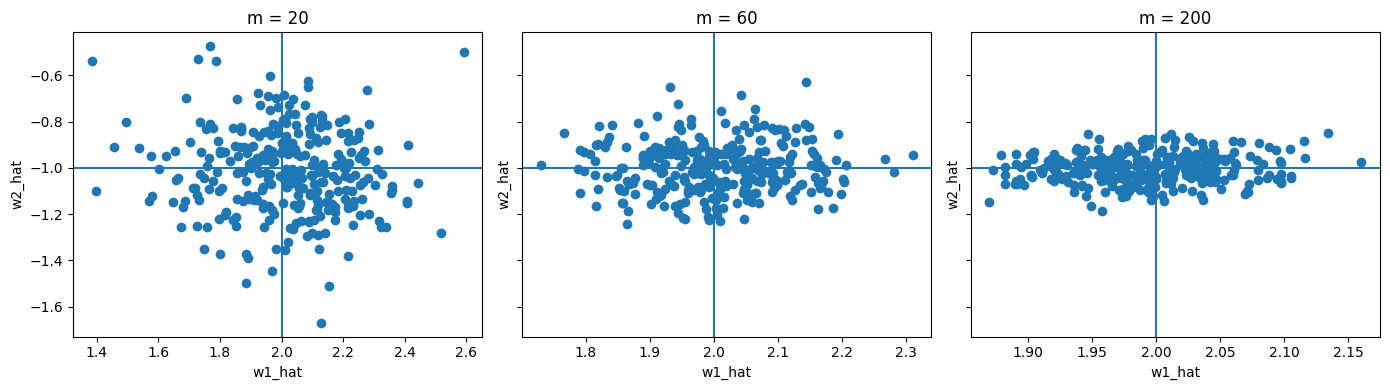

Varianza de coeficientes vs m (sin intercepto) ===
m=20: Var(w1)=0.0375, Var(w2)=0.0335
m=60: Var(w1)=0.0107, Var(w2)=0.0117
m=200: Var(w1)=0.0030, Var(w2)=0.0039


Métricas promedio (diferentes ruidos) ===
m=20: MSE=0.5531, RMSE=0.7327, R^2=0.8877, sigma2_hat=0.6507
m=60: MSE=0.6090, RMSE=0.7771, R^2=0.8886, sigma2_hat=0.6410
m=200: MSE=0.6277, RMSE=0.7913, R^2=0.8876, sigma2_hat=0.6372


In [23]:
n = 2
sigma = 0.8
b_true = 0.3
w_true = np.array([2.0, -1.0])

# Cantidad de datos
m_list = [20, 60, 200]
T = 300
W = {}
metrics_mean = {}

for m in m_list:
    Wh = []
    ms = []
    for _ in range(T):
        X, y = make_linear_data(rng, m, n, sigma, w_true, b_true)
        w_hat, y_hat, residual, X_design = ols_fit(X, y)
        Wh.append(w_hat[1:])
        ms.append(regression_metrics(y, y_hat, residual, X_design))
    W[m] = np.stack(Wh)

    metrics_mean[m] = {
        k: float(np.mean([d[k] for d in ms if np.isfinite(d[k])]))
        for k in ["RSS", "MSE", "RMSE", "MAE", "R2", "sigma2_hat"]
    }

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, m in zip(axes, m_list):
    ax.scatter(W[m][:, 0], W[m][:, 1])
    ax.axvline(w_true[0])
    ax.axhline(w_true[1])
    ax.set_title(f"m = {m}")
    ax.set_xlabel("w1_hat")
    ax.set_ylabel("w2_hat")

plt.tight_layout()
plt.show()

print("Varianza de coeficientes vs m (sin intercepto) ===")
for m in m_list:
    var = W[m].var(axis=0)
    print(f"m={m}: Var(w1)={var[0]:.4f}, Var(w2)={var[1]:.4f}")

print("\n")
print("Métricas promedio (diferentes ruidos) ===")
for m in m_list:
    mm = metrics_mean[m]
    print(f"m={m}: MSE={mm['MSE']:.4f}, RMSE={mm['RMSE']:.4f}, R^2={mm['R2']:.4f}, sigma2_hat={mm['sigma2_hat']:.4f}")


### Colinealidad e inestabilidad

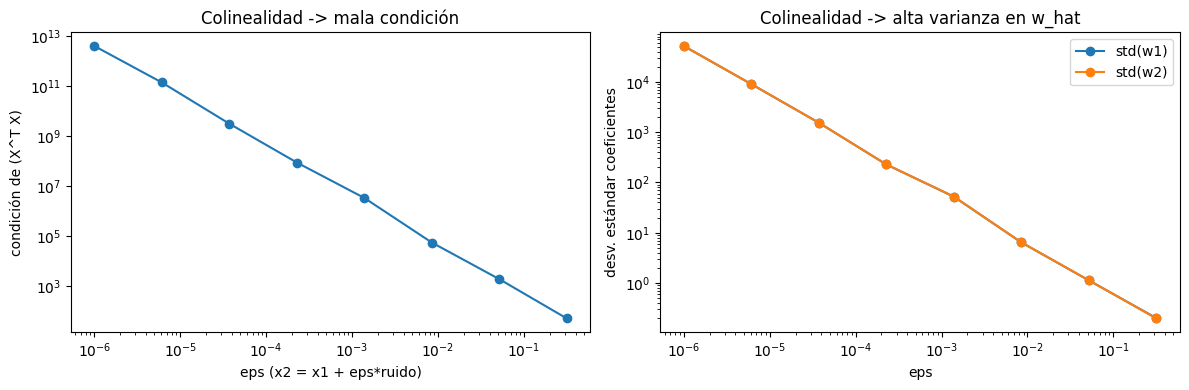

R^2 promedio vs colinealidad
eps=1.00e-06: R^2_mean=0.7681
eps=6.11e-06: R^2_mean=0.7639
eps=3.73e-05: R^2_mean=0.7350
eps=2.28e-04: R^2_mean=0.7615
eps=1.39e-03: R^2_mean=0.7559
eps=8.48e-03: R^2_mean=0.7192
eps=5.18e-02: R^2_mean=0.7592
eps=3.16e-01: R^2_mean=0.7759


In [26]:
m = 120
sigma = 0.6
b_true = 0.0
w_true = np.array([2.0, -1.0])

eps_list = np.logspace(-6, -0.5, 8)
T = 200
conds = []
spread = []
r2_mean = []

for eps in eps_list:
    x1 = rng.normal(size=m)
    x2 = x1 + eps * rng.normal(size=m)
    X = np.column_stack([x1, x2])

    X_design = np.c_[np.ones((m, 1)), X]
    XtX = X_design.T @ X_design
    cond, _ = condition_number_sym_psd(XtX)
    conds.append(cond)

    Wh = []
    r2s = []
    for _ in range(T):
        y = X @ w_true + b_true + rng.normal(0, sigma, size=m)
        w_hat, y_hat, residual, Xd = ols_fit(X, y)
        Wh.append(w_hat[1:])
        r2s.append(regression_metrics(y, y_hat, residual, Xd)["R2"])
    Wh = np.stack(Wh)
    spread.append(Wh.std(axis=0))
    r2_mean.append(float(np.mean(r2s)))

spread = np.stack(spread)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(eps_list, conds, marker="o")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("eps (magnitud del ruido)")
axes[0].set_ylabel("condición de (X^T X)")
axes[0].set_title("Colinealidad")

axes[1].plot(eps_list, spread[:, 0], marker="o", label="std(w1)")
axes[1].plot(eps_list, spread[:, 1], marker="o", label="std(w2)")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("eps")
axes[1].set_ylabel("desv. estándar coeficientes")
axes[1].set_title("Colinealidad -> alta varianza en w_hat")
axes[1].legend()

plt.tight_layout()
plt.show()

print("R^2 promedio vs colinealidad")
for eps, r2 in zip(eps_list, r2_mean):
    print(f"eps={eps:.2e}: R^2_mean={r2:.4f}")

### Mala especificación

Underfitting ======
  m=140, p=2
  RSS=1229.9610
  MSE=8.7854, RMSE=2.9640, MAE=2.5281
  R^2=0.3077
  sigma^2_hat (df)=8.9128




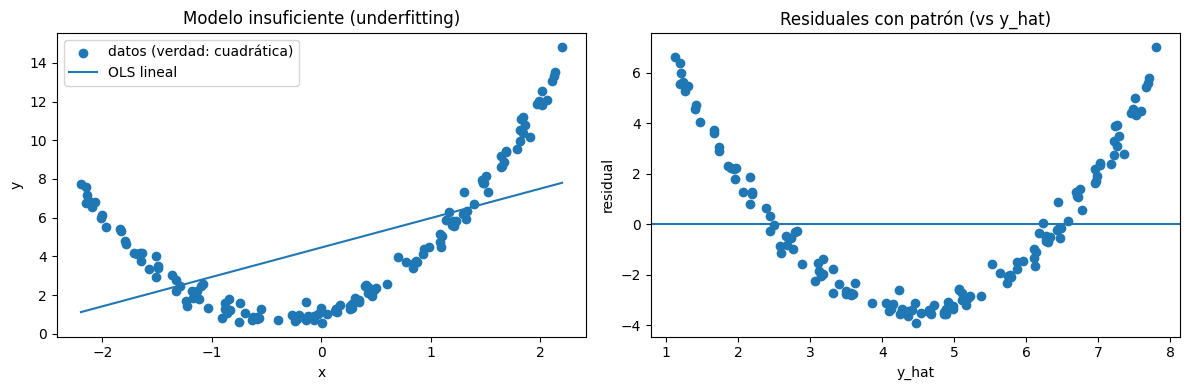

In [31]:
m = 140
sigma = 0.35

x = rng.uniform(-2.2, 2.2, size=m)
y = 1.0 + 1.5*x + 2.0*x**2 + rng.normal(0, sigma, size=m)  # verdad no lineal

X = x.reshape(-1, 1)
w_hat, y_hat, residual, X_design = ols_fit(X, y)
metrics = regression_metrics(y, y_hat, residual, X_design)

print("Underfitting ======")
print_metrics(metrics, prefix="  ")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

x_plot = np.linspace(x.min(), x.max(), 200)
Xp = np.c_[np.ones((x_plot.size, 1)), x_plot.reshape(-1, 1)]
y_plot = Xp @ w_hat

print("\n")

axes[0].scatter(x, y, label="datos (verdad: cuadrática)")
axes[0].plot(x_plot, y_plot, label="OLS lineal")
axes[0].set_title("Modelo insuficiente (underfitting)")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].legend()

axes[1].scatter(y_hat, residual)
axes[1].axhline(0)
axes[1].set_title("Residuales con patrón (vs y_hat)")
axes[1].set_xlabel("y_hat")
axes[1].set_ylabel("residual")

plt.tight_layout()
plt.show()

### Heterocedasticidad

Heterocedasticidad ===
  m=160, p=2
  RSS=51.2071
  MSE=0.3200, RMSE=0.5657, MAE=0.3623
  R^2=0.8984
  sigma^2_hat (df)=0.3241


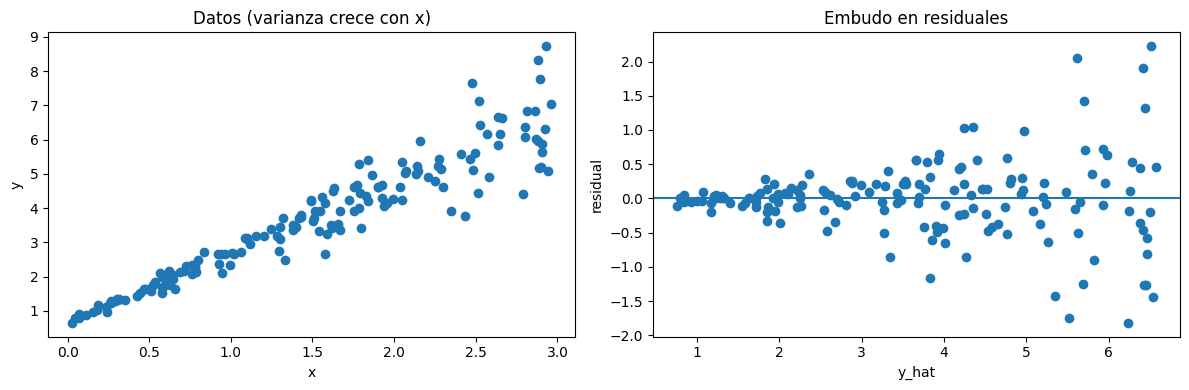

In [37]:
m = 160
x = rng.uniform(0, 3.0, size=m)

noise = rng.normal(0, 0.15 * (0.5 + x**2), size=m)  # var crece con x
y = 0.7 + 2.0*x + noise

X = x.reshape(-1, 1)
w_hat, y_hat, residual, X_design = ols_fit(X, y)
metrics = regression_metrics(y, y_hat, residual, X_design)

print("Heterocedasticidad ===")
print_metrics(metrics, prefix="  ")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(x, y)
axes[0].set_title("Datos (varianza crece con x)")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")

axes[1].scatter(y_hat, residual)
axes[1].axhline(0)
axes[1].set_title("Embudo en residuales")
axes[1].set_xlabel("y_hat")
axes[1].set_ylabel("residual")

plt.tight_layout()
plt.show()